# Fundamentos de Ciências de Dados

## IPV/ESTGL 2025/2026
## Mestrado em Controlo de Gestão e Ciência de Dados

### Hélder Vieira nº23678   
### Bruno Barros nº3547

## 🚨 Dados da Autoridade Nacional da Proteção Civil

### Enquadramento Inicial

A proteção civil é uma área de grande relevância pública, especialmente num país como Portugal, onde a geografia e as condições climáticas tornam certas regiões vulneráveis a eventos extremos como incêndios florestais, cheias e outros riscos naturais. A Autoridade Nacional de Emergência e Proteção Civil (ANEPC) desempenha um papel estratégico não só na resposta a crises, mas também na prevenção e planeamento de mitigação de riscos. 

Recentemente, a ANEPC tem desenvolvido iniciativas para consolidar uma base de dados nacional de danos associados a catástrofes, utilizando sistemas georreferenciados para recolher e analisar informações em tempo quase real. 

Essa base de dados multirrisco permite avaliar perdas humanas, materiais e económicas, apoiando a tomada de decisão estratégica na gestão de emergências. 

Além disso, a proteção civil em Portugal está organizada segundo uma estrutura institucional clara, com comandos regionais, sub-regionais e a Força Especial de Proteção Civil, o que permite uma coordenação eficaz e uma resposta adaptada ao território.

### Definição do Problema

Apesar da existência destes repositórios de dados e estruturas organizacionais, desafios persistem:

Fragmentação da Informação: Os dados de diferentes entidades (municipais, regionais, nacionais) podem estar dispersos, dificultando análises integradas de risco e de ocorrência.

Falta de Transparência Temporoespacial: Para uma gestão preditiva eficaz, é necessário ter séries históricas e georreferenciadas, mas nem sempre todos os dados estão acessíveis ou bem estruturados.

Capacidade de Resposta Baseada em Dados: Sem ferramentas analíticas bem desenvolvidas, a tomada de decisão pode depender mais da experiência institucional do que de evidência quantitativa.

Integração com Dados Externos: Para uma análise de risco robusta, seria vantajoso cruzar dados de proteção civil com outras bases: meteorológicas, demográficas, de uso do solo, infraestruturas, etc.

### Origem e Acesso aos Dados

Os dados utilizados nesta análise provêm do projeto Central de Dados, uma iniciativa pública que consolida informações oficiais de várias entidades governamentais portuguesas. O repositório oficial encontra-se disponível no GitHub:

Repositório:
https://github.com/centraldedados/protecao_civil

A Autoridade Nacional de Emergência e Proteção Civil (ANEPC) é a entidade responsável pela publicação original das ocorrências. O repositório do Central de Dados recolhe automaticamente estas informações diárias, criando uma base histórica acessível em formatos abertos como CSV e JSON.

Os datasets analisados (anpc-2016.csv, anpc-2017.csv, anpc-2018.csv, anpc-2019.csv , anpc-2020.csv) foram descarregados diretamente do repositório e carregados no ambiente de trabalho Jupyter Notebook através da função pd.read_csv.

Qualquer utilizador pode obter estes dados acedendo ao repositório acima e descarregando os ficheiros correspondentes ao ano pretendido.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error
import math

import matplotlib.pyplot as plt
from ipywidgets import interact, Dropdown

In [2]:
df_2016 = pd.read_csv("../data/anpc-2016.csv", low_memory = False )

In [3]:
df_2016.head()

,Numero,DataOcorrencia,DataFechoOperacional,Natureza,EstadoOcorrencia,Distrito,Concelho,Freguesia,Localidade,Latitude,Longitude,NumeroMeiosTerrestresEnvolvidos,NumeroOperacionaisTerrestresEnvolvidos,NumeroMeiosAereosEnvolvidos,NumeroOperacionaisAereosEnvolvidos
0,2016150002576,09/01/2016 14:02:00,09/01/2016 17:30:00,Protecção e Assistência a Pessoas e Bens / Ass...,Encerrada,SETÚBAL,MOITA,Gaio-Rosário e Sarilhos Pequenos,Gaio- Rosario,"38,68091202","-9,002235449",1.0,3.0,0.0,0.0
1,2016010098470,10/01/2016 00:30:00,NaN,Protecção e Assistência a Pessoas e Bens / Ass...,Em Curso,AVEIRO,ALBERGARIA-A-VELHA,Albergaria-a-Velha e Valmaior,Rua 25 de Abril - Assilhó - Albergaria-a-Velha,"40,6927855","-8,479686736",0.0,0.0,0.0,0.0
2,2016020002249,24/01/2016 18:57:00,24/01/2016 19:53:00,Protecção e Assistência a Pessoas e Bens / Ass...,Encerrada,BEJA,CASTRO VERDE,Castro Verde e Casével,"CASTRO VERDE-Rua Bento J. Carraça,6","37,71278977","-8,091107843",2.0,4.0,0.0,0.0
3,2016050041560,30/01/2016 23:38:00,NaN,Protecção e Assistência a Pessoas e Bens / Ass...,Em Curso,CASTELO BRANCO,VILA DE REI,Vila de Rei,Vila de Rei,"39,6684201","-8,146938534",1.0,2.0,0.0,0.0
4,2016020003825,13/02/2016 00:10:00,13/02/2016 01:35:00,Protecção e Assistência a Pessoas e Bens / Ass...,Encerrada,BEJA,CASTRO VERDE,Santa Bárbara de Padrões,"SETE-Rua da Graça, 4","37,6149714","-7,962115173",1.0,2.0,0.0,0.0


In [4]:
df_2017 = pd.read_csv("../data/anpc-2017.csv", low_memory = False )

In [5]:
df_2017.head()

,Numero,DataOcorrencia,DataFechoOperacional,Natureza,EstadoOcorrencia,Distrito,Concelho,Freguesia,Localidade,Latitude,Longitude,NumeroMeiosTerrestresEnvolvidos,NumeroOperacionaisTerrestresEnvolvidos,NumeroMeiosAereosEnvolvidos,NumeroOperacionaisAereosEnvolvidos
0,2017150000311,01/01/2017 23:54:00,02/01/2017 02:20:00,Protecção e Assistência a Pessoas e Bens / Ass...,Encerrada,SETÚBAL,PALMELA,Poceirão e Marateca,Aroeira,"38,633484","-8,747517",1.0,2.0,0.0,0.0
1,2017040000077,01/01/2017 23:49:00,NaN,Protecção e Assistência a Pessoas e Bens / Ass...,Conclusão,BRAGANÇA,VIMIOSO,Santulhão,SANTULHÃO,"41,56556219","-6,616623316",0.0,0.0,0.0,0.0
2,2017110000697,01/01/2017 23:45:00,NaN,Protecção e Assistência a Pessoas e Bens / Ass...,Despacho,LISBOA,CASCAIS,Cascais e Estoril,São Pedro do Estoril,"38,695541","-9,372595",0.0,0.0,0.0,0.0
3,2017180000176,01/01/2017 23:43:00,02/01/2017 02:15:00,Protecção e Assistência a Pessoas e Bens / Ass...,Encerrada,VISEU,NELAS,Nelas,Nelas,"40,5209163","-7,855737521",1.0,2.0,0.0,0.0
4,2017110000695,01/01/2017 23:37:00,NaN,Protecção e Assistência a Pessoas e Bens / Ass...,Despacho de 1º Alerta,LISBOA,LISBOA,Marvila,MARVILA,"38,73910415","-9,110710285",1.0,2.0,0.0,0.0


In [6]:
df_2018 = pd.read_csv("../data/anpc-2018.csv")

In [7]:
df_2018.head()

,Numero,DataOcorrencia,DataFechoOperacional,Natureza,EstadoOcorrencia,Distrito,Concelho,Freguesia,Localidade,Latitude,Longitude,NumeroMeiosTerrestresEnvolvidos,NumeroOperacionaisTerrestresEnvolvidos,NumeroMeiosAereosEnvolvidos,NumeroOperacionaisAereosEnvolvidos
0,2018110000766,01/01/2018 23:51:00,NaN,Protecção e Assistência a Pessoas e Bens / Ass...,Despacho de 1º Alerta,LISBOA,LISBOA,Misericórdia,RUA DA TROMBETA Nº1 - SPA,"38,70544128","-9,146675288",1,3,0,0
1,2018170000089,01/01/2018 23:47:00,NaN,Protecção e Assistência a Pessoas e Bens / Ass...,Despacho de 1º Alerta,VILA REAL,VILA REAL,"Nossa Senhora da Conceição, São Pedro e São Dinis",Vila Real,"41,2939689326323","-7,74273985430003",1,2,0,0
2,2018110000763,01/01/2018 23:42:00,NaN,Protecção e Assistência a Pessoas e Bens / Ass...,Despacho de 1º Alerta,LISBOA,LISBOA,Belém,BELÉM,"38,6922265998961","-9,21695998417107",1,2,0,0
3,2018130000663,01/01/2018 23:41:00,NaN,Riscos Tecnológicos / Acidentes / Despiste,Despacho de 1º Alerta,PORTO,PENAFIEL,Penafiel,PENAFIEL,"41,208503","-8,306815",5,12,0,0
4,2018110000765,01/01/2018 23:40:00,NaN,Riscos Mistos / Incêndios em Detritos / Detrit...,Conclusão,LISBOA,SINTRA,Massamá e Monte Abraão,Massamá,"38,753778","-9,280008",1,6,0,0


In [8]:
df_2019 = pd.read_csv("../data/anpc-2019.csv")

In [9]:
df_2019.head()

,Numero,DataOcorrencia,DataFechoOperacional,Natureza,EstadoOcorrencia,Distrito,Concelho,Freguesia,Localidade,Latitude,Longitude,NumeroMeiosTerrestresEnvolvidos,NumeroOperacionaisTerrestresEnvolvidos,NumeroMeiosAereosEnvolvidos,NumeroOperacionaisAereosEnvolvidos
0,2019140000224,2019-01-01T23:44:00,2019-01-02T00:26:00,Riscos Mistos / Comprometimento total ou parci...,Encerrada,SANTARÉM,SANTARÉM,"Marvila, Ribeira Santarém, S.Salvador, S.Nicolau",STR#VALE_ESTACAS,39.245248,-8.691192,2,6,False,0
1,2019180000150,2019-01-01T23:32:00,NaN,Riscos Tecnológicos / Acidentes / Despiste,Conclusão,VISEU,SÁTÃO,Avelal,AVELAL,40.753810,-7.679058,3,6,False,0
2,2019010000253,2019-01-01T23:27:00,2019-01-02T02:03:00,Protecção e Assistência a Pessoas e Bens / Ass...,Encerrada,AVEIRO,ÁGUEDA,Fermentelos,Fermentelos,40.564917,-8.528591,1,2,False,0
3,2019160000096,2019-01-01T23:23:00,2019-01-02T00:31:00,Riscos Mistos / Incêndios Rurais / Mato,Encerrada,VIANA DO CASTELO,MELGAÇO,Parada do Monte e Cubalhão,CUBALHÃO,42.051770,-8.227085,2,9,False,0
4,2019180000148,2019-01-01T23:08:00,2019-01-02T02:37:00,Protecção e Assistência a Pessoas e Bens / Ass...,Encerrada,VISEU,CASTRO DAIRE,Parada de Ester e Ester,PARADA DE ESTER,40.932635,-8.071387,1,2,False,0


In [10]:
df_2020 = pd.read_csv("../data/anpc-2020.csv")

In [11]:
df_2020.head()

,Numero,DataOcorrencia,DataFechoOperacional,Natureza,EstadoOcorrencia,Distrito,Concelho,Freguesia,Localidade,Latitude,Longitude,NumeroMeiosTerrestresEnvolvidos,NumeroOperacionaisTerrestresEnvolvidos,NumeroMeiosAereosEnvolvidos,NumeroOperacionaisAereosEnvolvidos
0,2020110000794,2020-01-01T23:52:00,2020-01-02T01:00:00,Protecção e Assistência a Pessoas e Bens / Int...,Encerrada,LISBOA,SINTRA,Agualva e Mira-Sintra,Agualva,38.769933,-9.294104,1,2,False,False
1,2020110000787,2020-01-01T23:40:00,2020-01-02T01:20:00,Protecção e Assistência a Pessoas e Bens / Ass...,Encerrada,LISBOA,OEIRAS,Barcarena,Barcarena,38.735194,-9.280259,1,2,False,False
2,2020120000059,2020-01-01T23:27:00,NaN,Protecção e Assistência a Pessoas e Bens / Ass...,Em Curso,PORTALEGRE,ELVAS,Santa Eulália,Santa Eulália,39.009201,-7.263009,0,0,False,False
3,2020020000087,2020-01-01T23:26:00,NaN,Protecção e Assistência a Pessoas e Bens / Int...,Despacho de 1º Alerta,BEJA,BEJA,Cabeça Gorda,CABEÇA GORDA,37.923848,-7.802110,2,4,False,False
4,2020170000090,2020-01-01T23:23:00,NaN,Protecção e Assistência a Pessoas e Bens / Ass...,Despacho de 1º Alerta,VILA REAL,VILA REAL,"Nossa Senhora da Conceição, São Pedro e São Dinis",Vila Real,41.293969,-7.742740,1,2,False,False


In [12]:
# 1. Criar um dicionário para associar o Nome (texto) ao DataFrame (variável)
# Isto ajuda a saber qual é qual no print
dicionario_dfs = {
    "ANPC 2016": df_2016,
    "ANPC 2017": df_2017,
    "ANPC 2018": df_2018,
    "ANPC 2019": df_2019,
    "ANPC 2020": df_2020
}

# 2. Percorrer cada um e mostrar os dados
for nome, df in dicionario_dfs.items():
    print("=" * 60)
    print(f" PAINEL DE INFORMAÇÃO: {nome}")
    print("=" * 60)
    
    # a) Shape (Linhas e Colunas)
    # df.shape[0] são as linhas, df.shape[1] são as colunas
    print(f"📌 DIMENSÕES (Shape):")
    print(f"   -> Linhas:   {df.shape[0]}")
    print(f"   -> Colunas:  {df.shape[1]}")
    print("-" * 30)

    # b) Nomes das Colunas
    print(f"📋 COLUNAS:")
    # list(df.columns) torna a leitura mais limpa que o index bruto
    print(list(df.columns))
    print("-" * 30)
    
    # c) Info Geral (Tipos e Nulos)
    print(f"ℹ️ INFO DETALHADA:")
    df.info()
    
    print("\n\n") # Espaço extra entre cada ano

 PAINEL DE INFORMAÇÃO: ANPC 2016
📌 DIMENSÕES (Shape):
   -> Linhas:   121187
   -> Colunas:  15
------------------------------
📋 COLUNAS:
['Numero', 'DataOcorrencia', 'DataFechoOperacional', 'Natureza', 'EstadoOcorrencia', 'Distrito', 'Concelho', 'Freguesia', 'Localidade', 'Latitude', 'Longitude', 'NumeroMeiosTerrestresEnvolvidos', 'NumeroOperacionaisTerrestresEnvolvidos', 'NumeroMeiosAereosEnvolvidos', 'NumeroOperacionaisAereosEnvolvidos']
------------------------------
ℹ️ INFO DETALHADA:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121187 entries, 0 to 121186
Data columns (total 15 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   Numero                                  121187 non-null  object 
 1   DataOcorrencia                          121182 non-null  object 
 2   DataFechoOperacional                    120744 non-null  object 
 3   Natureza                               

In [13]:
def limpar_dados_anpc(df):
    # Fazer uma cópia para evitar avisos de 'SettingWithCopy'
    df_clean = df.copy()
    
    # 1. TRATAMENTO DE DATAS
    # Converte as colunas de data. O pandas é inteligente o suficiente para 
    # detetar se é ISO (2019-01-01) ou PT (01/01/2019), mas forçamos 'mixed' para segurança.
    colunas_data = ['DataOcorrencia', 'DataFechoOperacional']
    for col in colunas_data:
        if col in df_clean.columns:
            # errors='coerce' transforma valores inválidos em NaT (Not a Time)
            df_clean[col] = pd.to_datetime(df_clean[col], dayfirst=True, errors='coerce')

    # 2. TRATAMENTO DE COORDENADAS (Vírgula para Ponto)
    # Lista de colunas que costumam ser coordenadas
    colunas_coord = ['Latitude', 'Longitude']
    for col in colunas_coord:
        if col in df_clean.columns:
            # Se a coluna for do tipo 'object' (string), substitui vírgula por ponto
            if df_clean[col].dtype == 'object':
                df_clean[col] = df_clean[col].astype(str).str.replace(',', '.', regex=False)
            # Converte para numérico
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

    # 3. TRATAMENTO DE VALORES 'FALSE' EM COLUNAS NUMÉRICAS
    # Nas colunas de meios/operacionais, substituir 'False' ou False por 0
    cols_meios = [
        'NumeroMeiosTerrestresEnvolvidos', 'NumeroOperacionaisTerrestresEnvolvidos',
        'NumeroMeiosAereosEnvolvidos', 'NumeroOperacionaisAereosEnvolvidos'
    ]
    
    for col in cols_meios:
        if col in df_clean.columns:
            # Substitui o booleano False e a string 'False' por 0
            df_clean[col] = df_clean[col].replace({False: 0, 'False': 0})
            # Garante que é numérico (float ou int)
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce').fillna(0)

    return df_clean

print("Função de limpeza definida com sucesso.")

Função de limpeza definida com sucesso.


In [16]:
# Lista dos teus dataframes originais
lista_dfs = [df_2016, df_2017, df_2018, df_2019, df_2020]

# Aplicar a limpeza a cada um e guardar numa nova lista
dfs_limpos = [limpar_dados_anpc(df) for df in lista_dfs]

# Concatenar tudo num único DataFrame
df_total = pd.concat(dfs_limpos, ignore_index=True)

# Verificar o resultado final
print(f"Total de registos carregados: {df_total.shape[0]}")
print(f"Intervalo de datas: de {df_total['DataOcorrencia'].min()} a {df_total['DataOcorrencia'].max()}")

# Espreitar os tipos de dados para garantir que ficou tudo certo
df_total.info()

Total de registos carregados: 910783
Intervalo de datas: de 2016-01-09 14:02:00 a 2020-12-06 23:51:00
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 910783 entries, 0 to 910782
Data columns (total 15 columns):
 #   Column                                  Non-Null Count   Dtype         
---  ------                                  --------------   -----         
 0   Numero                                  910783 non-null  object        
 1   DataOcorrencia                          705543 non-null  datetime64[ns]
 2   DataFechoOperacional                    506097 non-null  datetime64[ns]
 3   Natureza                                910778 non-null  object        
 4   EstadoOcorrencia                        910778 non-null  object        
 5   Distrito                                910778 non-null  object        
 6   Concelho                                910778 non-null  object        
 7   Freguesia                               910776 non-null  object        
 8   Localidade  

In [18]:
df_total

,Numero,DataOcorrencia,DataFechoOperacional,Natureza,EstadoOcorrencia,Distrito,Concelho,Freguesia,Localidade,Latitude,Longitude,NumeroMeiosTerrestresEnvolvidos,NumeroOperacionaisTerrestresEnvolvidos,NumeroMeiosAereosEnvolvidos,NumeroOperacionaisAereosEnvolvidos
0,2016150002576,2016-01-09 14:02:00,2016-01-09 17:30:00,Protecção e Assistência a Pessoas e Bens / Ass...,Encerrada,SETÚBAL,MOITA,Gaio-Rosário e Sarilhos Pequenos,Gaio- Rosario,38.680912,-9.002235,1.0,3.0,0.0,0.0
1,2016010098470,2016-01-10 00:30:00,NaT,Protecção e Assistência a Pessoas e Bens / Ass...,Em Curso,AVEIRO,ALBERGARIA-A-VELHA,Albergaria-a-Velha e Valmaior,Rua 25 de Abril - Assilhó - Albergaria-a-Velha,40.692785,-8.479687,0.0,0.0,0.0,0.0
2,2016020002249,2016-01-24 18:57:00,2016-01-24 19:53:00,Protecção e Assistência a Pessoas e Bens / Ass...,Encerrada,BEJA,CASTRO VERDE,Castro Verde e Casével,"CASTRO VERDE-Rua Bento J. Carraça,6",37.712790,-8.091108,2.0,4.0,0.0,0.0
3,2016050041560,2016-01-30 23:38:00,NaT,Protecção e Assistência a Pessoas e Bens / Ass...,Em Curso,CASTELO BRANCO,VILA DE REI,Vila de Rei,Vila de Rei,39.668420,-8.146939,1.0,2.0,0.0,0.0
4,2016020003825,2016-02-13 00:10:00,2016-02-13 01:35:00,Protecção e Assistência a Pessoas e Bens / Ass...,Encerrada,BEJA,CASTRO VERDE,Santa Bárbara de Padrões,"SETE-Rua da Graça, 4",37.614971,-7.962115,1.0,2.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
910778,2020150052723,2020-06-07 00:24:00,2020-06-07 01:31:00,Riscos Tecnológicos / Acidentes / Despiste,Encerrada,SETÚBAL,SEIXAL,Corroios,VALE_MILHACOS,38.618466,-9.155796,3.0,7.0,0.0,0.0
910779,2020050015721,2020-06-07 00:24:00,2020-06-07 02:15:00,Protecção e Assistência a Pessoas e Bens / Ass...,Encerrada,CASTELO BRANCO,IDANHA-A-NOVA,Idanha-a-Nova e Alcafozes,IDANHA-A-NOVA E ALCAFOZES,39.904527,-7.195744,1.0,2.0,0.0,0.0
910780,2020020014560,2020-06-07 00:19:00,2020-06-07 01:35:00,Protecção e Assistência a Pessoas e Bens / Ass...,Encerrada,BEJA,BEJA,Beja (Santiago Maior e São João Baptista),BEJA (SANTIAGO MAIOR E SÃO JOÃO BAPTISTA,38.011769,-7.902989,3.0,6.0,0.0,0.0
910781,2020080025467,2020-06-07 00:15:00,2020-06-07 01:10:00,Protecção e Assistência a Pessoas e Bens / Ass...,Encerrada,FARO,ALBUFEIRA,Albufeira e Olhos de Água,Areias de São João,37.090838,-8.239918,2.0,4.0,0.0,0.0


In [31]:
df_grouped = (
    df_total
    .groupby(["Freguesia"])
    .size()
    .reset_index(name="total")
    
)
df_grouped

,Freguesia,total
0,A dos Cunhados e Maceira,802
1,A dos Francos,119
2,A dos Negros,108
3,Abade de Neiva,112
4,Abadim,65
...,...,...
2704,"Évora (São Mamede, Sé, São Pedro e Santo Antão)",931
2705,Évora Monte (Santa Maria),92
2706,Évora de Alcobaça,285
2707,Ílhavo (São Salvador),1606


In [19]:
# Configuração de estilo dos gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

# 1. Criar colunas auxiliares de tempo
# Removemos linhas onde a data possa ser nula (erros de conversão)
df_total = df_total.dropna(subset=['DataOcorrencia'])

df_total['Ano'] = df_total['DataOcorrencia'].dt.year
df_total['Mes'] = df_total['DataOcorrencia'].dt.month
df_total['Hora'] = df_total['DataOcorrencia'].dt.hour
df_total['DiaSemana'] = df_total['DataOcorrencia'].dt.day_name()

print("Colunas temporais (Ano, Mes, Hora) criadas com sucesso.")

Colunas temporais (Ano, Mes, Hora) criadas com sucesso.


C:\Users\Daniel\AppData\Local\Temp\ipykernel_7204\2413302590.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_total['Ano'] = df_total['DataOcorrencia'].dt.year
C:\Users\Daniel\AppData\Local\Temp\ipykernel_7204\2413302590.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_total['Mes'] = df_total['DataOcorrencia'].dt.month
C:\Users\Daniel\AppData\Local\Temp\ipykernel_7204\2413302590.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row

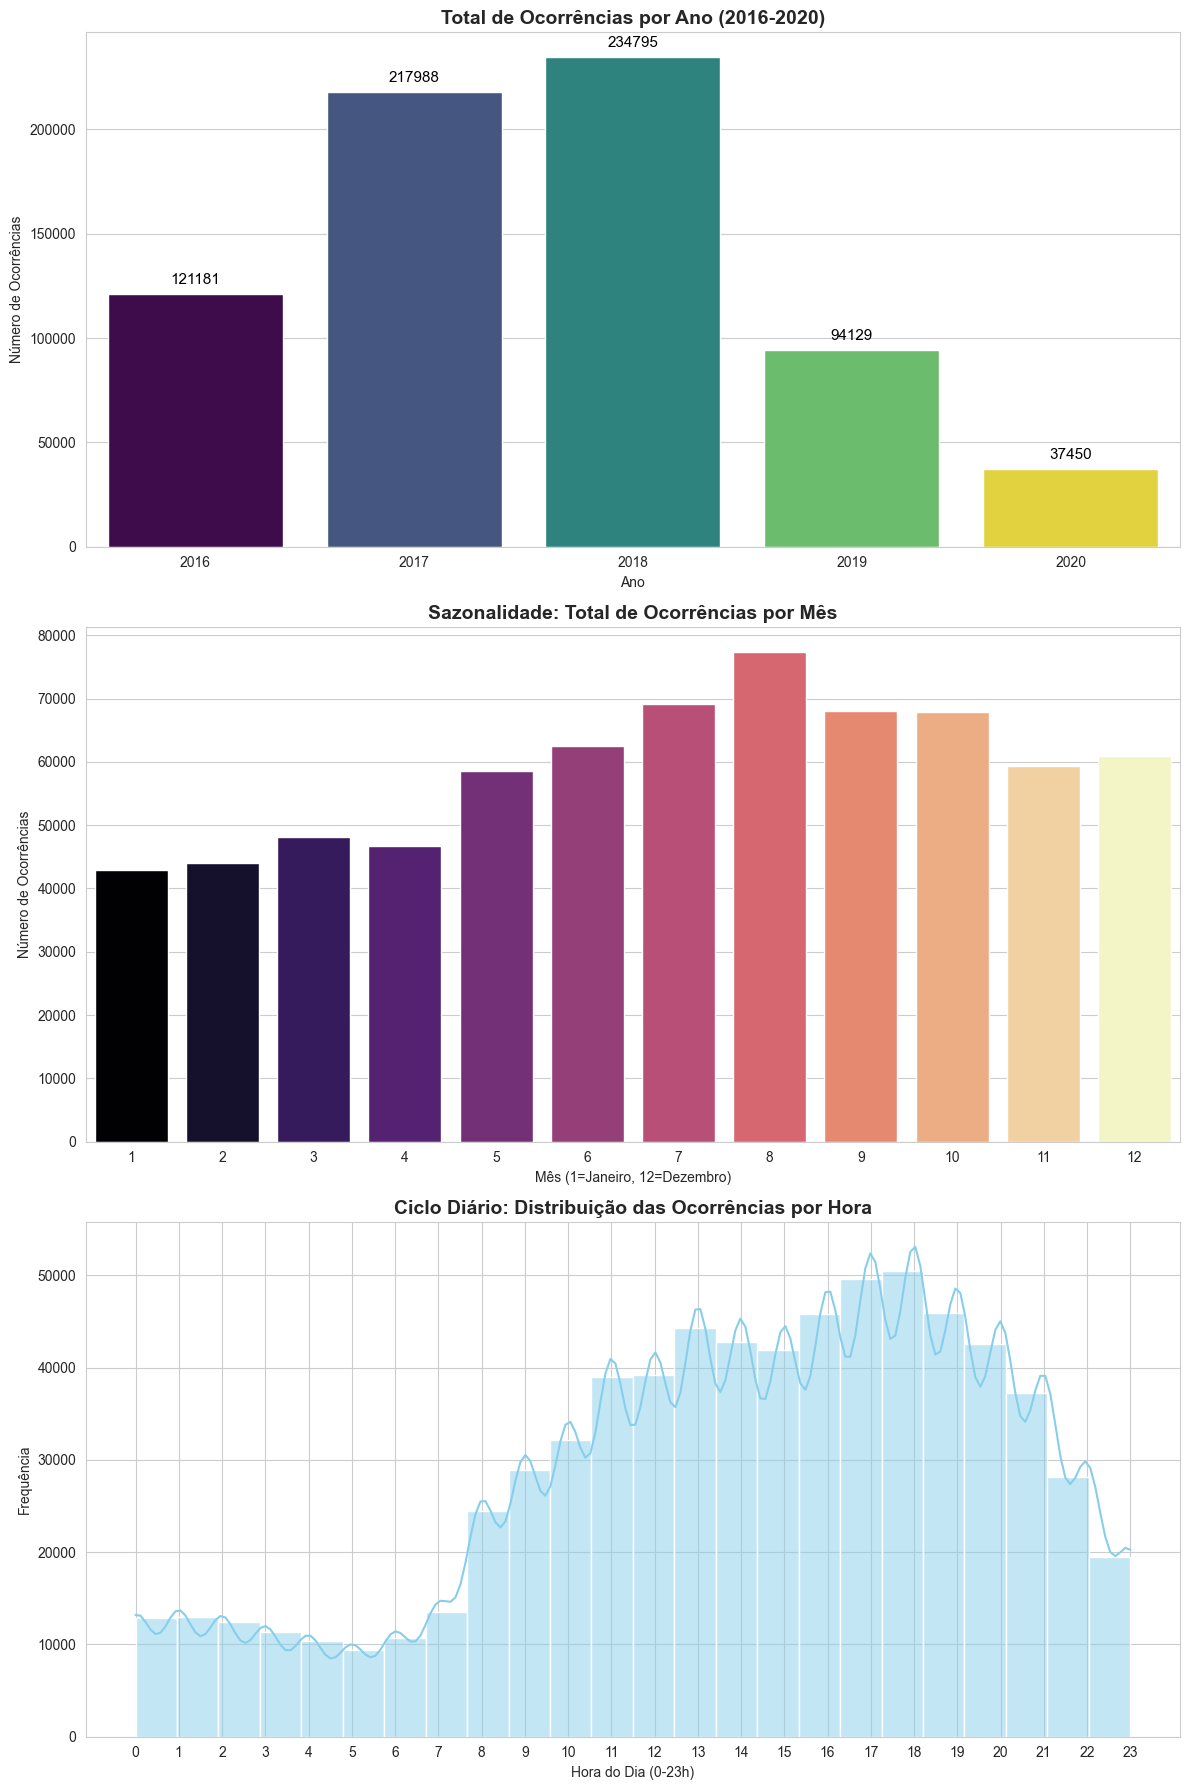

In [28]:
# Criar uma figura com 3 subplots (linhas)
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# --- GRÁFICO 1: Evolução Anual ---
sns.countplot(x='Ano', data=df_total, hue='Ano', palette='viridis', ax=axes[0], legend=False)
axes[0].set_title('Total de Ocorrências por Ano (2016-2020)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Número de Ocorrências')
axes[0].set_xlabel('Ano')
# Adicionar o valor em cima de cada barra
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 5),
                     textcoords='offset points')

# --- GRÁFICO 2: Sazonalidade Mensal (Agregado) ---
sns.countplot(x='Mes', data=df_total, hue='Mes', palette='magma', ax=axes[1], legend=False)
axes[1].set_title('Sazonalidade: Total de Ocorrências por Mês', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Número de Ocorrências')
axes[1].set_xlabel('Mês (1=Janeiro, 12=Dezembro)')

# --- GRÁFICO 3: Ciclo Diário (Por Hora) ---
sns.histplot(data=df_total, x='Hora', bins=24, kde=True, color='skyblue', ax=axes[2])
axes[2].set_title('Ciclo Diário: Distribuição das Ocorrências por Hora', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Frequência')
axes[2].set_xlabel('Hora do Dia (0-23h)')
axes[2].set_xticks(range(0, 24))

plt.tight_layout()
plt.show()

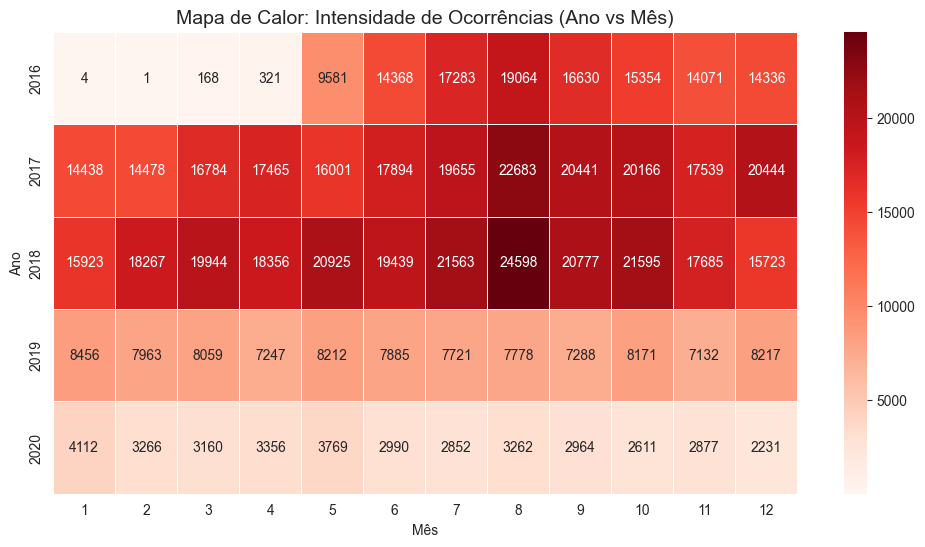

In [21]:
# Criar tabela dinâmica (Pivot Table) contanto ocorrências por Ano e Mês
pivot_ocorrencias = df_total.groupby(['Ano', 'Mes']).size().unstack()

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_ocorrencias, annot=True, fmt='d', cmap='Reds', linewidths=.5)
plt.title('Mapa de Calor: Intensidade de Ocorrências (Ano vs Mês)', fontsize=14)
plt.xlabel('Mês')
plt.ylabel('Ano')
plt.show()

In [ ]:
A distribuição das ocorrências ao longo dos meses evidencia um padrão sazonal, com maior concentração em determinados períodos do ano. Este comportamento pode estar associado a fenómenos climáticos sazonais ou a períodos de maior atividade humana. Estes resultados são particularmente úteis para o planeamento antecipado de meios e definição de estratégias preventivas.


In [22]:
# 1. Filtrar apenas ocorrências que contêm "Incêndio" na descrição da Natureza
# case=False garante que apanha "Incêndio", "incêndio", "INCÊNDIO"
df_incendios = df_total[df_total['Natureza'].str.contains('Incêndio', case=False, na=False)].copy()

# 2. Normalizar o nome dos Distritos (tudo em maiúsculas) para evitar duplicados
df_incendios['Distrito'] = df_incendios['Distrito'].astype(str).str.upper()

# Verificar quantos registos sobraram
print(f"Total de registos de Incêndios (2016-2020): {df_incendios.shape[0]}")
print(f"Isto representa {df_incendios.shape[0] / df_total.shape[0] * 100:.1f}% de todas as ocorrências.")

Total de registos de Incêndios (2016-2020): 105364
Isto representa 14.9% de todas as ocorrências.


C:\Users\bruno.barros\AppData\Local\Temp\ipykernel_692\2406272684.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_distritos_freq.values, y=top_distritos_freq.index, palette='Reds_r', ax=axes[0])
C:\Users\bruno.barros\AppData\Local\Temp\ipykernel_692\2406272684.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_distritos_ops.values, y=top_distritos_ops.index, palette='Oranges_r', ax=axes[1])


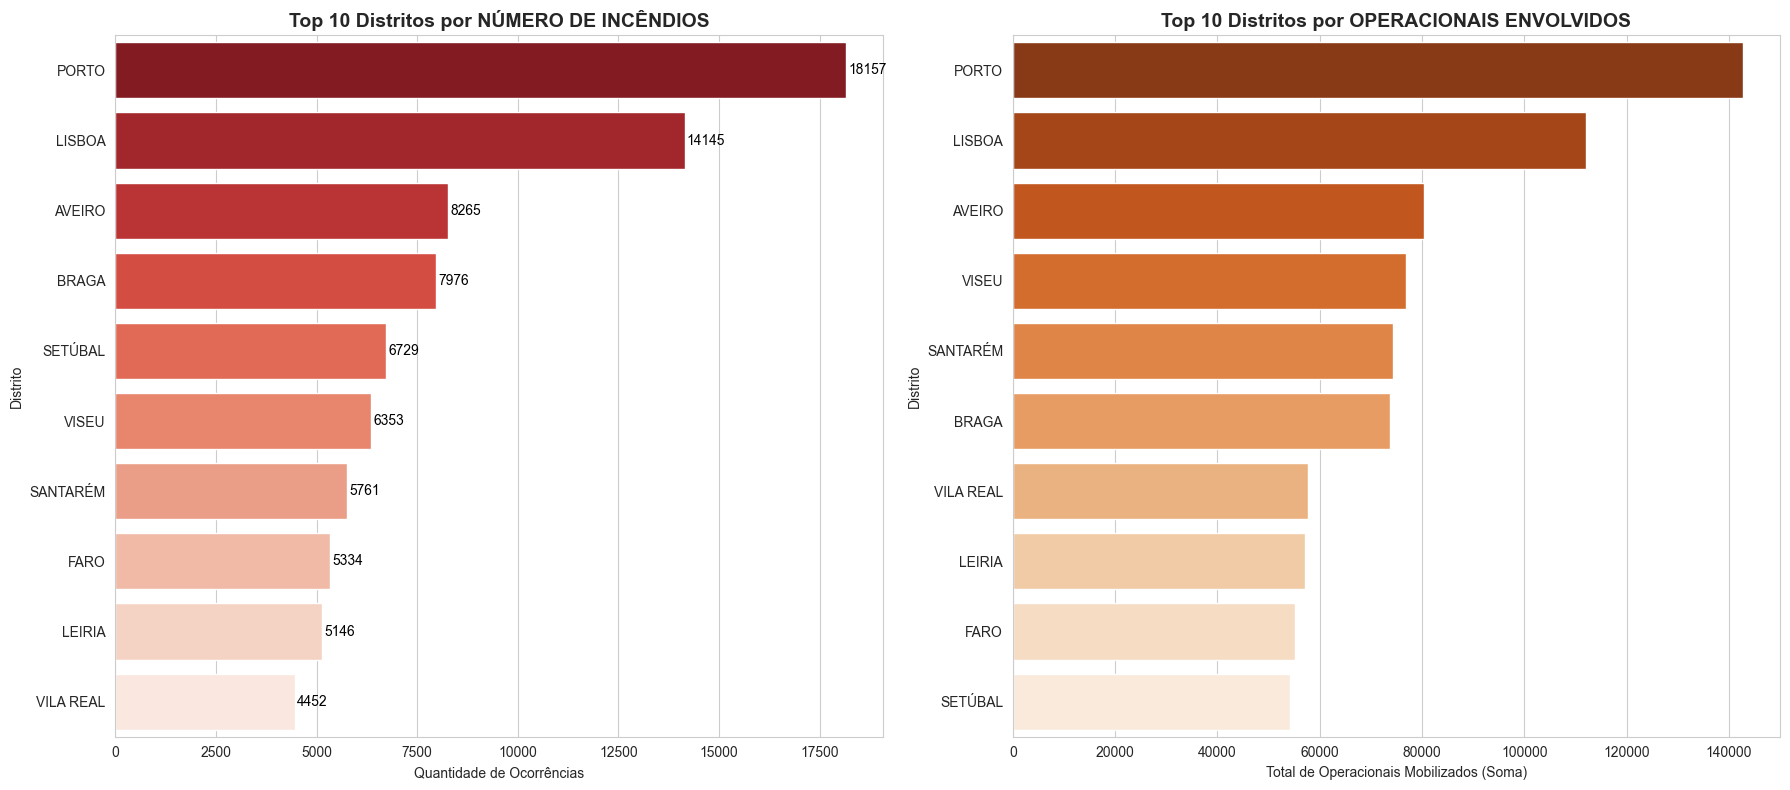

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar a área de plotagem (2 gráficos)
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# --- GRÁFICO 1: Distritos com MAIOR NÚMERO DE INCÊNDIOS (Frequência) ---
top_distritos_freq = df_incendios['Distrito'].value_counts().head(10)

sns.barplot(x=top_distritos_freq.values, y=top_distritos_freq.index, palette='Reds_r', ax=axes[0])
axes[0].set_title('Top 10 Distritos por NÚMERO DE INCÊNDIOS', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Quantidade de Ocorrências')
# Adicionar valores nas barras
for i, v in enumerate(top_distritos_freq.values):
    axes[0].text(v + 50, i, str(v), color='black', va='center')

# --- GRÁFICO 2: Distritos com MAIS OPERACIONAIS MOBILIZADOS (Gravidade/Esforço) ---
# Agrupar por distrito e somar o número de operacionais terrestres
top_distritos_ops = df_incendios.groupby('Distrito')['NumeroOperacionaisTerrestresEnvolvidos'].sum().sort_values(ascending=False).head(10)

sns.barplot(x=top_distritos_ops.values, y=top_distritos_ops.index, palette='Oranges_r', ax=axes[1])
axes[1].set_title('Top 10 Distritos por OPERACIONAIS ENVOLVIDOS', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Total de Operacionais Mobilizados (Soma)')

plt.tight_layout()
plt.show()

In [24]:
# 1. Criar uma Macro-Categoria (apanha o texto antes da primeira barra '/')
# Ex: "Riscos Mistos / Incêndios..." passa a ser apenas "Riscos Mistos"
df_total['MacroCategoria'] = df_total['Natureza'].astype(str).apply(lambda x: x.split('/')[0].strip())

# 2. Calcular estatísticas por Macro-Categoria
# count = número de ocorrências
# sum = total de operacionais (custo total de recursos humanos)
# mean = média de operacionais por evento (intensidade)
resumo_recursos = df_total.groupby('MacroCategoria')['NumeroOperacionaisTerrestresEnvolvidos'].agg(['count', 'sum', 'mean'])

# Ordenar pelo total de operacionais para o gráfico
resumo_recursos = resumo_recursos.sort_values(by='sum', ascending=False)

print("Tabela Resumo (Top 5 Categorias por Total de Operacionais):")
display(resumo_recursos.head())

C:\Users\bruno.barros\AppData\Local\Temp\ipykernel_692\3388562455.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_total['MacroCategoria'] = df_total['Natureza'].astype(str).apply(lambda x: x.split('/')[0].strip())


Tabela Resumo (Top 5 Categorias por Total de Operacionais):


,count,sum,mean
MacroCategoria,,,
Protecção e Assistência a Pessoas e Bens,499084,1252009.0,2.508614
Riscos Mistos,100643,895942.0,8.902179
Riscos Tecnológicos,103675,693113.0,6.685440
Operações e Estados de Alerta,1991,24423.0,12.266700
Riscos Naturais,150,764.0,5.093333


In [34]:
A distribuição dos tipos de ocorrência revela que algumas categorias concentram a maioria dos registos. 
Este resultado indica que a atividade da Proteção Civil está fortemente associada a um conjunto reduzido de tipos de eventos, 
o que pode refletir padrões recorrentes de risco. Esta informação é relevante para o planeamento operacional, 
permitindo priorizar recursos e ações de prevenção focadas nos tipos de ocorrência mais frequentes.


SyntaxError: invalid syntax (918858880.py, line 1)

C:\Users\bruno.barros\AppData\Local\Temp\ipykernel_692\617169714.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=resumo_recursos['sum'], y=resumo_recursos.index, palette='Blues_r', ax=axes[0])
C:\Users\bruno.barros\AppData\Local\Temp\ipykernel_692\617169714.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=resumo_intensidade['mean'], y=resumo_intensidade.index, palette='Oranges_r', ax=axes[1])


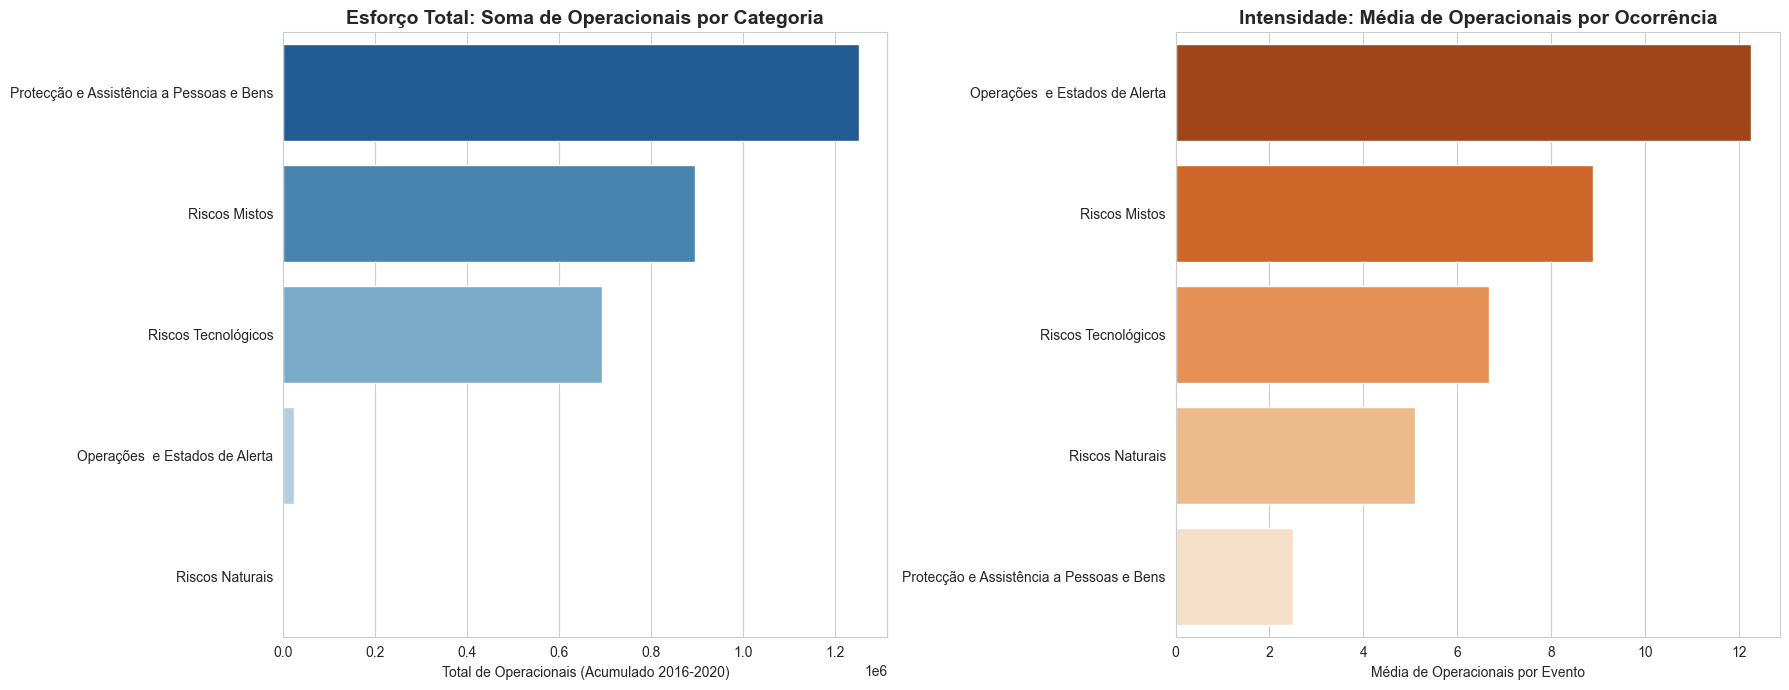

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- GRÁFICO 1: Onde estão a ser gastos os recursos totais? (SOMA) ---
sns.barplot(x=resumo_recursos['sum'], y=resumo_recursos.index, palette='Blues_r', ax=axes[0])
axes[0].set_title('Esforço Total: Soma de Operacionais por Categoria', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Total de Operacionais (Acumulado 2016-2020)')
axes[0].set_ylabel('')

# --- GRÁFICO 2: Qual o evento mais "caro" em média? (MÉDIA) ---
# Reordenar pelos que exigem mais gente por evento
resumo_intensidade = resumo_recursos.sort_values(by='mean', ascending=False)

sns.barplot(x=resumo_intensidade['mean'], y=resumo_intensidade.index, palette='Oranges_r', ax=axes[1])
axes[1].set_title('Intensidade: Média de Operacionais por Ocorrência', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Média de Operacionais por Evento')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

C:\Users\bruno.barros\AppData\Local\Temp\ipykernel_692\2989152542.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  top_plot = sns.barplot(x=top_especificos.values, y=top_especificos.index, palette='Reds_r')


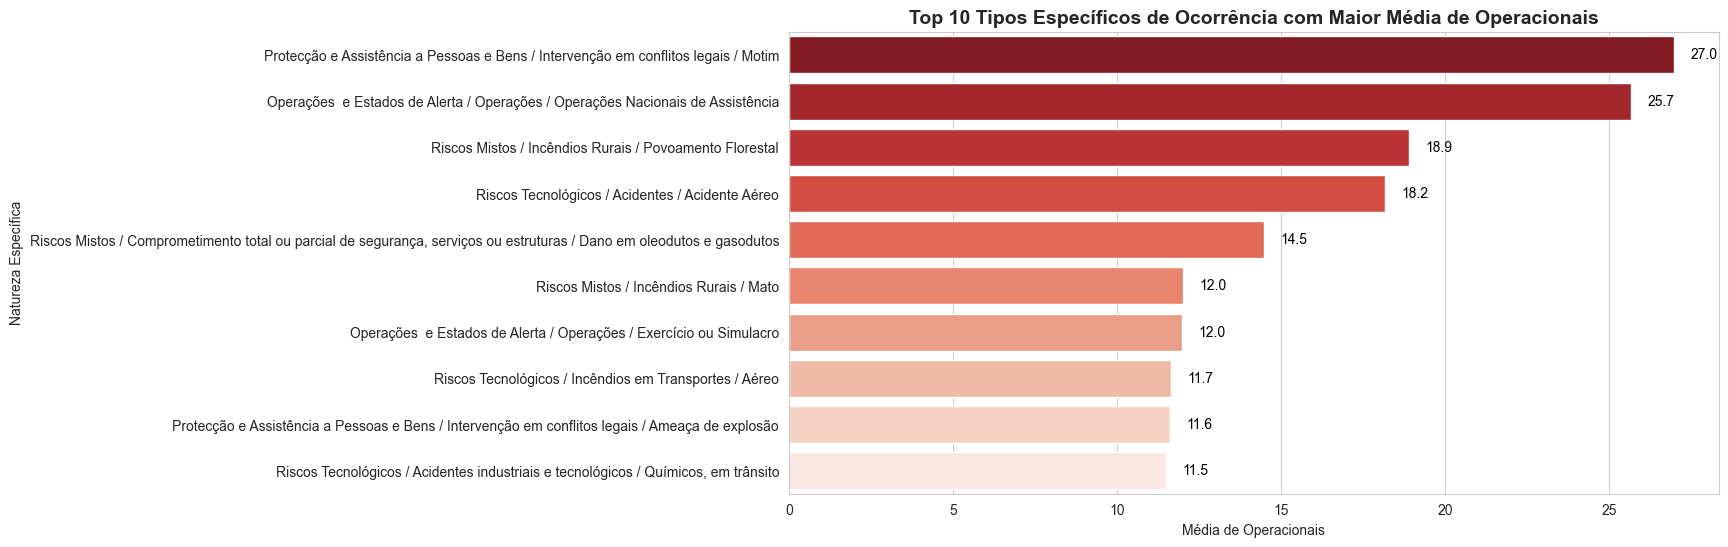

In [26]:
# Agrupar pela descrição completa da Natureza
top_especificos = df_total.groupby('Natureza')['NumeroOperacionaisTerrestresEnvolvidos'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
top_plot = sns.barplot(x=top_especificos.values, y=top_especificos.index, palette='Reds_r')
plt.title('Top 10 Tipos Específicos de Ocorrência com Maior Média de Operacionais', fontsize=14, fontweight='bold')
plt.xlabel('Média de Operacionais')
plt.ylabel('Natureza Específica')

# Adicionar o valor na ponta das barras
for i, v in enumerate(top_especificos.values):
    plt.text(v + 0.5, i, f"{v:.1f}", color='black', va='center')

plt.show()

In [ ]:
Esta é uma etapa crucial. Estamos a deixar de "olhar para o passado" (EDA) para começar a "prever o futuro" (Machine Learning).
Para este exercício, vamos definir um problema de Regressão.

Objetivo: Prever quantos operacionais serão necessários (NumeroOperacionaisTerrestresEnvolvidos) com base no tipo de ocorrência, hora e local. Isto ajudaria a ANEPC a planear recursos.
Aqui está o guião passo-a-passo aplicado aos teus dados:

1. Identificação do Alvo (Target)
Para uma tarefa de aprendizagem supervisionada, o nosso alvo (y) será:
NumeroOperacionaisTerrestresEnvolvidos
As nossas características (X) (features) serão:
Natureza (ou MacroCategoria)
Distrito
DataOcorrencia (decomposta em Mês, Hora, Dia da Semana)
Latitude / Longitude


### Visualizar a Distribuição do Alvo

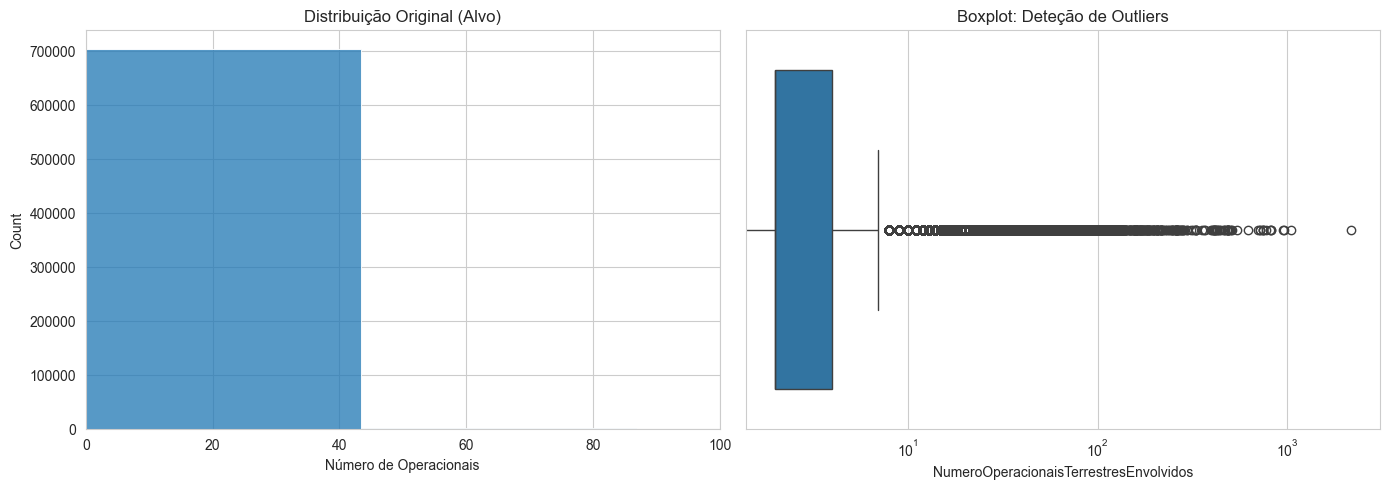

Máximo de operacionais num evento: 2170.0
Média de operacionais: 4.06247528499326


In [50]:
plt.figure(figsize=(14, 5))

# Gráfico 1: Distribuição Original (Limitada a 50 para ver melhor a maioria)
plt.subplot(1, 2, 1)
sns.histplot(df_total['NumeroOperacionaisTerrestresEnvolvidos'], bins=50, kde=False)
plt.title('Distribuição Original (Alvo)')
plt.xlabel('Número de Operacionais')
plt.xlim(0, 100) # Cortamos visualmente os outliers extremos para ver a base

# Gráfico 2: Boxplot para ver os Outliers
plt.subplot(1, 2, 2)
sns.boxplot(x=df_total['NumeroOperacionaisTerrestresEnvolvidos'])
plt.title('Boxplot: Deteção de Outliers')
plt.xscale('log') # Escala logarítmica para conseguir ver os extremos (incêndios grandes)

plt.tight_layout()
plt.show()

# Estatísticas básicas
print("Máximo de operacionais num evento:", df_total['NumeroOperacionaisTerrestresEnvolvidos'].max())
print("Média de operacionais:", df_total['NumeroOperacionaisTerrestresEnvolvidos'].mean())

### Estudo de Correlações

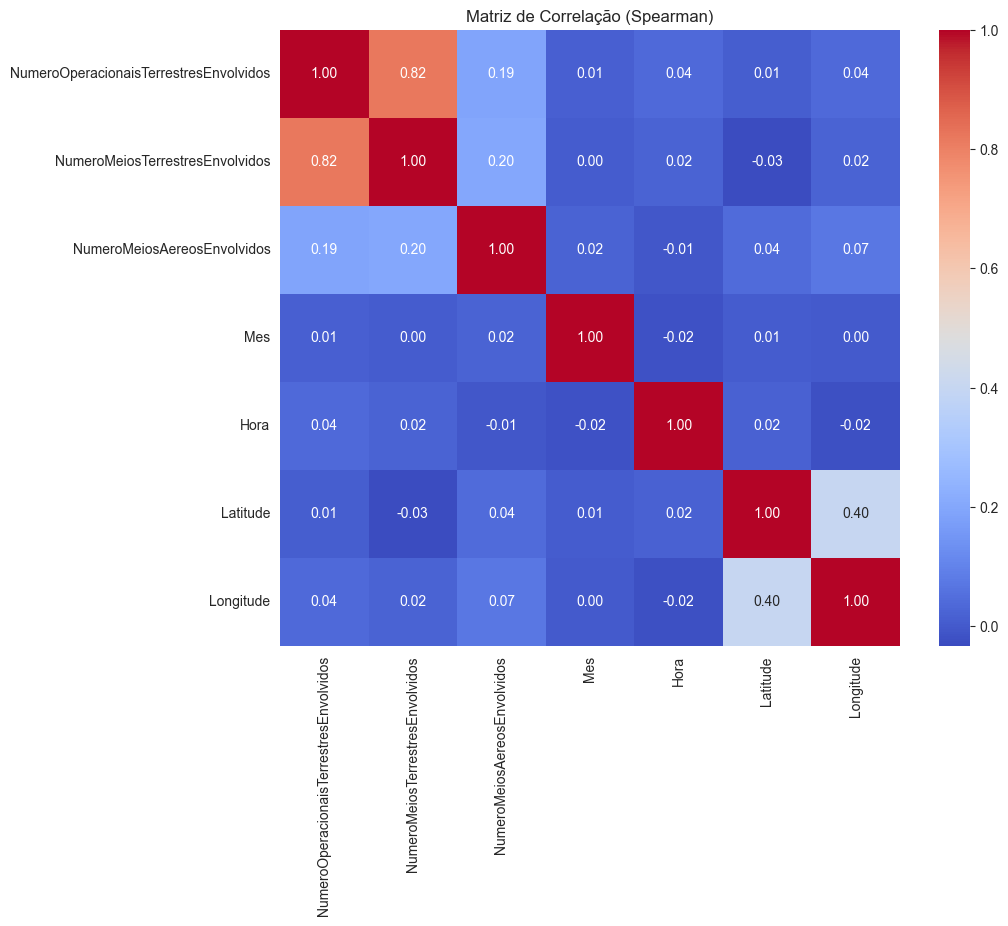

In [51]:
# Selecionar apenas colunas numéricas para a correlação
cols_numericas = ['NumeroOperacionaisTerrestresEnvolvidos', 'NumeroMeiosTerrestresEnvolvidos', 
                  'NumeroMeiosAereosEnvolvidos', 'Mes', 'Hora', 'Latitude', 'Longitude']

# Calcular correlação de Spearman (melhor que Pearson para dados não-lineares/com outliers)
corr_matrix = df_total[cols_numericas].corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação (Spearman)')
plt.show()

### Como resolver o problema manualmente

In [54]:
# 1. Criar o modelo manual: Calcular a média de operacionais por 'MacroCategoria'
media_por_categoria = df_total.groupby('MacroCategoria')['NumeroOperacionaisTerrestresEnvolvidos'].mean()

# 2. Fazer "previsões" aplicando essa média a cada linha
df_total['Predicao_Manual'] = df_total['MacroCategoria'].map(media_por_categoria)

# 3. Tratar casos onde possa haver nulos (categorias novas)
df_total['Predicao_Manual'] = df_total['Predicao_Manual'].fillna(df_total['NumeroOperacionaisTerrestresEnvolvidos'].mean())

# 4. Calcular o erro (RMSE)
rmse_manual = np.sqrt(mean_squared_error(df_total['NumeroOperacionaisTerrestresEnvolvidos'], df_total['Predicao_Manual']))

print(f"BASELINE MANUAL (Média por Categoria):")
print(f"Se colocarnos sempre a média da categoria, erramos em média {rmse_manual:.2f} operacionais por ocorrência.")
print("Qualquer modelo de Machine Learning tem de ter um erro menor que este para ser útil.")

BASELINE MANUAL (Média por Categoria):
Se colocarnos sempre a média da categoria, erramos em média 7.65 operacionais por ocorrência.
Qualquer modelo de Machine Learning tem de ter um erro menor que este para ser útil.


### Transformações Promissoras

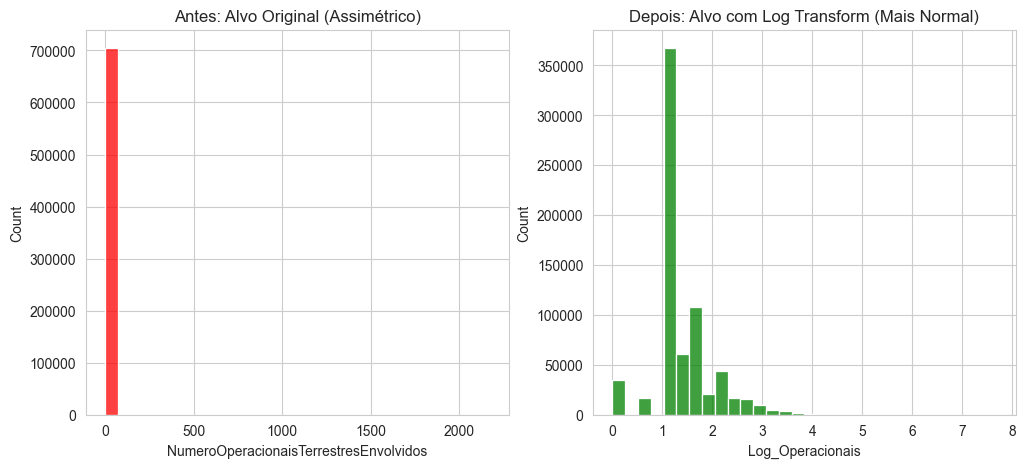

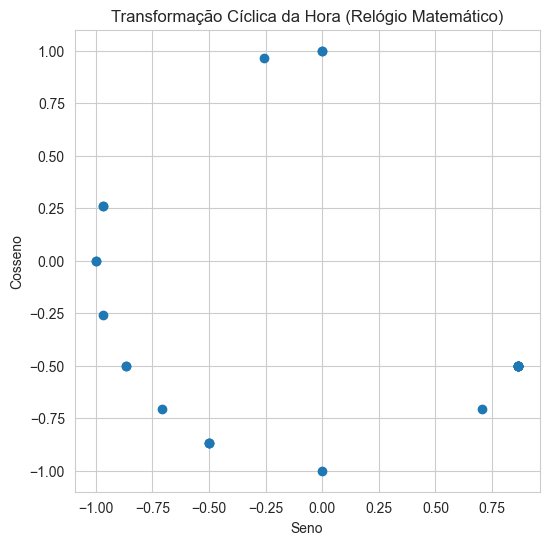

In [55]:
# --- TRANSFORMAÇÃO 1: Logaritmo no Alvo ---
# Aplicamos log1p (log(x+1)) para evitar log(0)
df_total['Log_Operacionais'] = np.log1p(df_total['NumeroOperacionaisTerrestresEnvolvidos'])

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_total['NumeroOperacionaisTerrestresEnvolvidos'], bins=30, color='red')
plt.title('Antes: Alvo Original (Assimétrico)')

plt.subplot(1, 2, 2)
sns.histplot(df_total['Log_Operacionais'], bins=30, color='green')
plt.title('Depois: Alvo com Log Transform (Mais Normal)')
plt.show()

# --- TRANSFORMAÇÃO 2: Tempo Cíclico (Hora) ---
# Transformar a Hora (0-23) em coordenadas de um círculo
df_total['Hora_Sin'] = np.sin(2 * np.pi * df_total['Hora']/24)
df_total['Hora_Cos'] = np.cos(2 * np.pi * df_total['Hora']/24)

# Visualizar a transformação cíclica (exemplo das primeiras 24h)
plt.figure(figsize=(6, 6))
plt.scatter(df_total['Hora_Sin'].head(24), df_total['Hora_Cos'].head(24))
plt.title('Transformação Cíclica da Hora (Relógio Matemático)')
plt.xlabel('Seno')
plt.ylabel('Cosseno')
plt.grid(True)
plt.show()

In [35]:
df_total.tail()

,Numero,DataOcorrencia,DataFechoOperacional,Natureza,EstadoOcorrencia,Distrito,Concelho,Freguesia,Localidade,Latitude,...,NumeroOperacionaisAereosEnvolvidos,Ano,Mes,Hora,DiaSemana,MacroCategoria,Predicao_Manual,Log_Operacionais,Hora_Sin,Hora_Cos
910778,2020150052723,2020-06-07 00:24:00,2020-06-07 01:31:00,Riscos Tecnológicos / Acidentes / Despiste,Encerrada,SETÚBAL,SEIXAL,Corroios,VALE_MILHACOS,38.618466,...,0.0,2020,6,0,Sunday,Riscos Tecnológicos,6.685440,2.079442,0.0,1.0
910779,2020050015721,2020-06-07 00:24:00,2020-06-07 02:15:00,Protecção e Assistência a Pessoas e Bens / Ass...,Encerrada,CASTELO BRANCO,IDANHA-A-NOVA,Idanha-a-Nova e Alcafozes,IDANHA-A-NOVA E ALCAFOZES,39.904527,...,0.0,2020,6,0,Sunday,Protecção e Assistência a Pessoas e Bens,2.508614,1.098612,0.0,1.0
910780,2020020014560,2020-06-07 00:19:00,2020-06-07 01:35:00,Protecção e Assistência a Pessoas e Bens / Ass...,Encerrada,BEJA,BEJA,Beja (Santiago Maior e São João Baptista),BEJA (SANTIAGO MAIOR E SÃO JOÃO BAPTISTA,38.011769,...,0.0,2020,6,0,Sunday,Protecção e Assistência a Pessoas e Bens,2.508614,1.945910,0.0,1.0
910781,2020080025467,2020-06-07 00:15:00,2020-06-07 01:10:00,Protecção e Assistência a Pessoas e Bens / Ass...,Encerrada,FARO,ALBUFEIRA,Albufeira e Olhos de Água,Areias de São João,37.090838,...,0.0,2020,6,0,Sunday,Protecção e Assistência a Pessoas e Bens,2.508614,1.609438,0.0,1.0
910782,2020150052721,2020-06-07 00:05:00,2020-06-07 01:25:00,Protecção e Assistência a Pessoas e Bens / Int...,Encerrada,SETÚBAL,SEIXAL,Corroios,VALE DE MILHAÇO,38.618840,...,0.0,2020,6,0,Sunday,Protecção e Assistência a Pessoas e Bens,2.508614,1.098612,0.0,1.0


Após a análise dos dados, foi identificado que a coluna Localidade contém registos com nomes escritos de formas diferentes para a mesma localidade, o que resulta na duplicação de dados.

Por exemplo, existem ocorrências com as designações “VALE_MILHACOS” e “VALE DE MILHAÇO”, ambas associadas ao Distrito de Setúbal, Concelho do Seixal e Freguesia de Corroios. Esta coincidência geográfica indica que se trata, muito provavelmente, da mesma localidade, sendo a diferença apenas decorrente de variações na escrita (uso de underscore, preposição e acentuação).

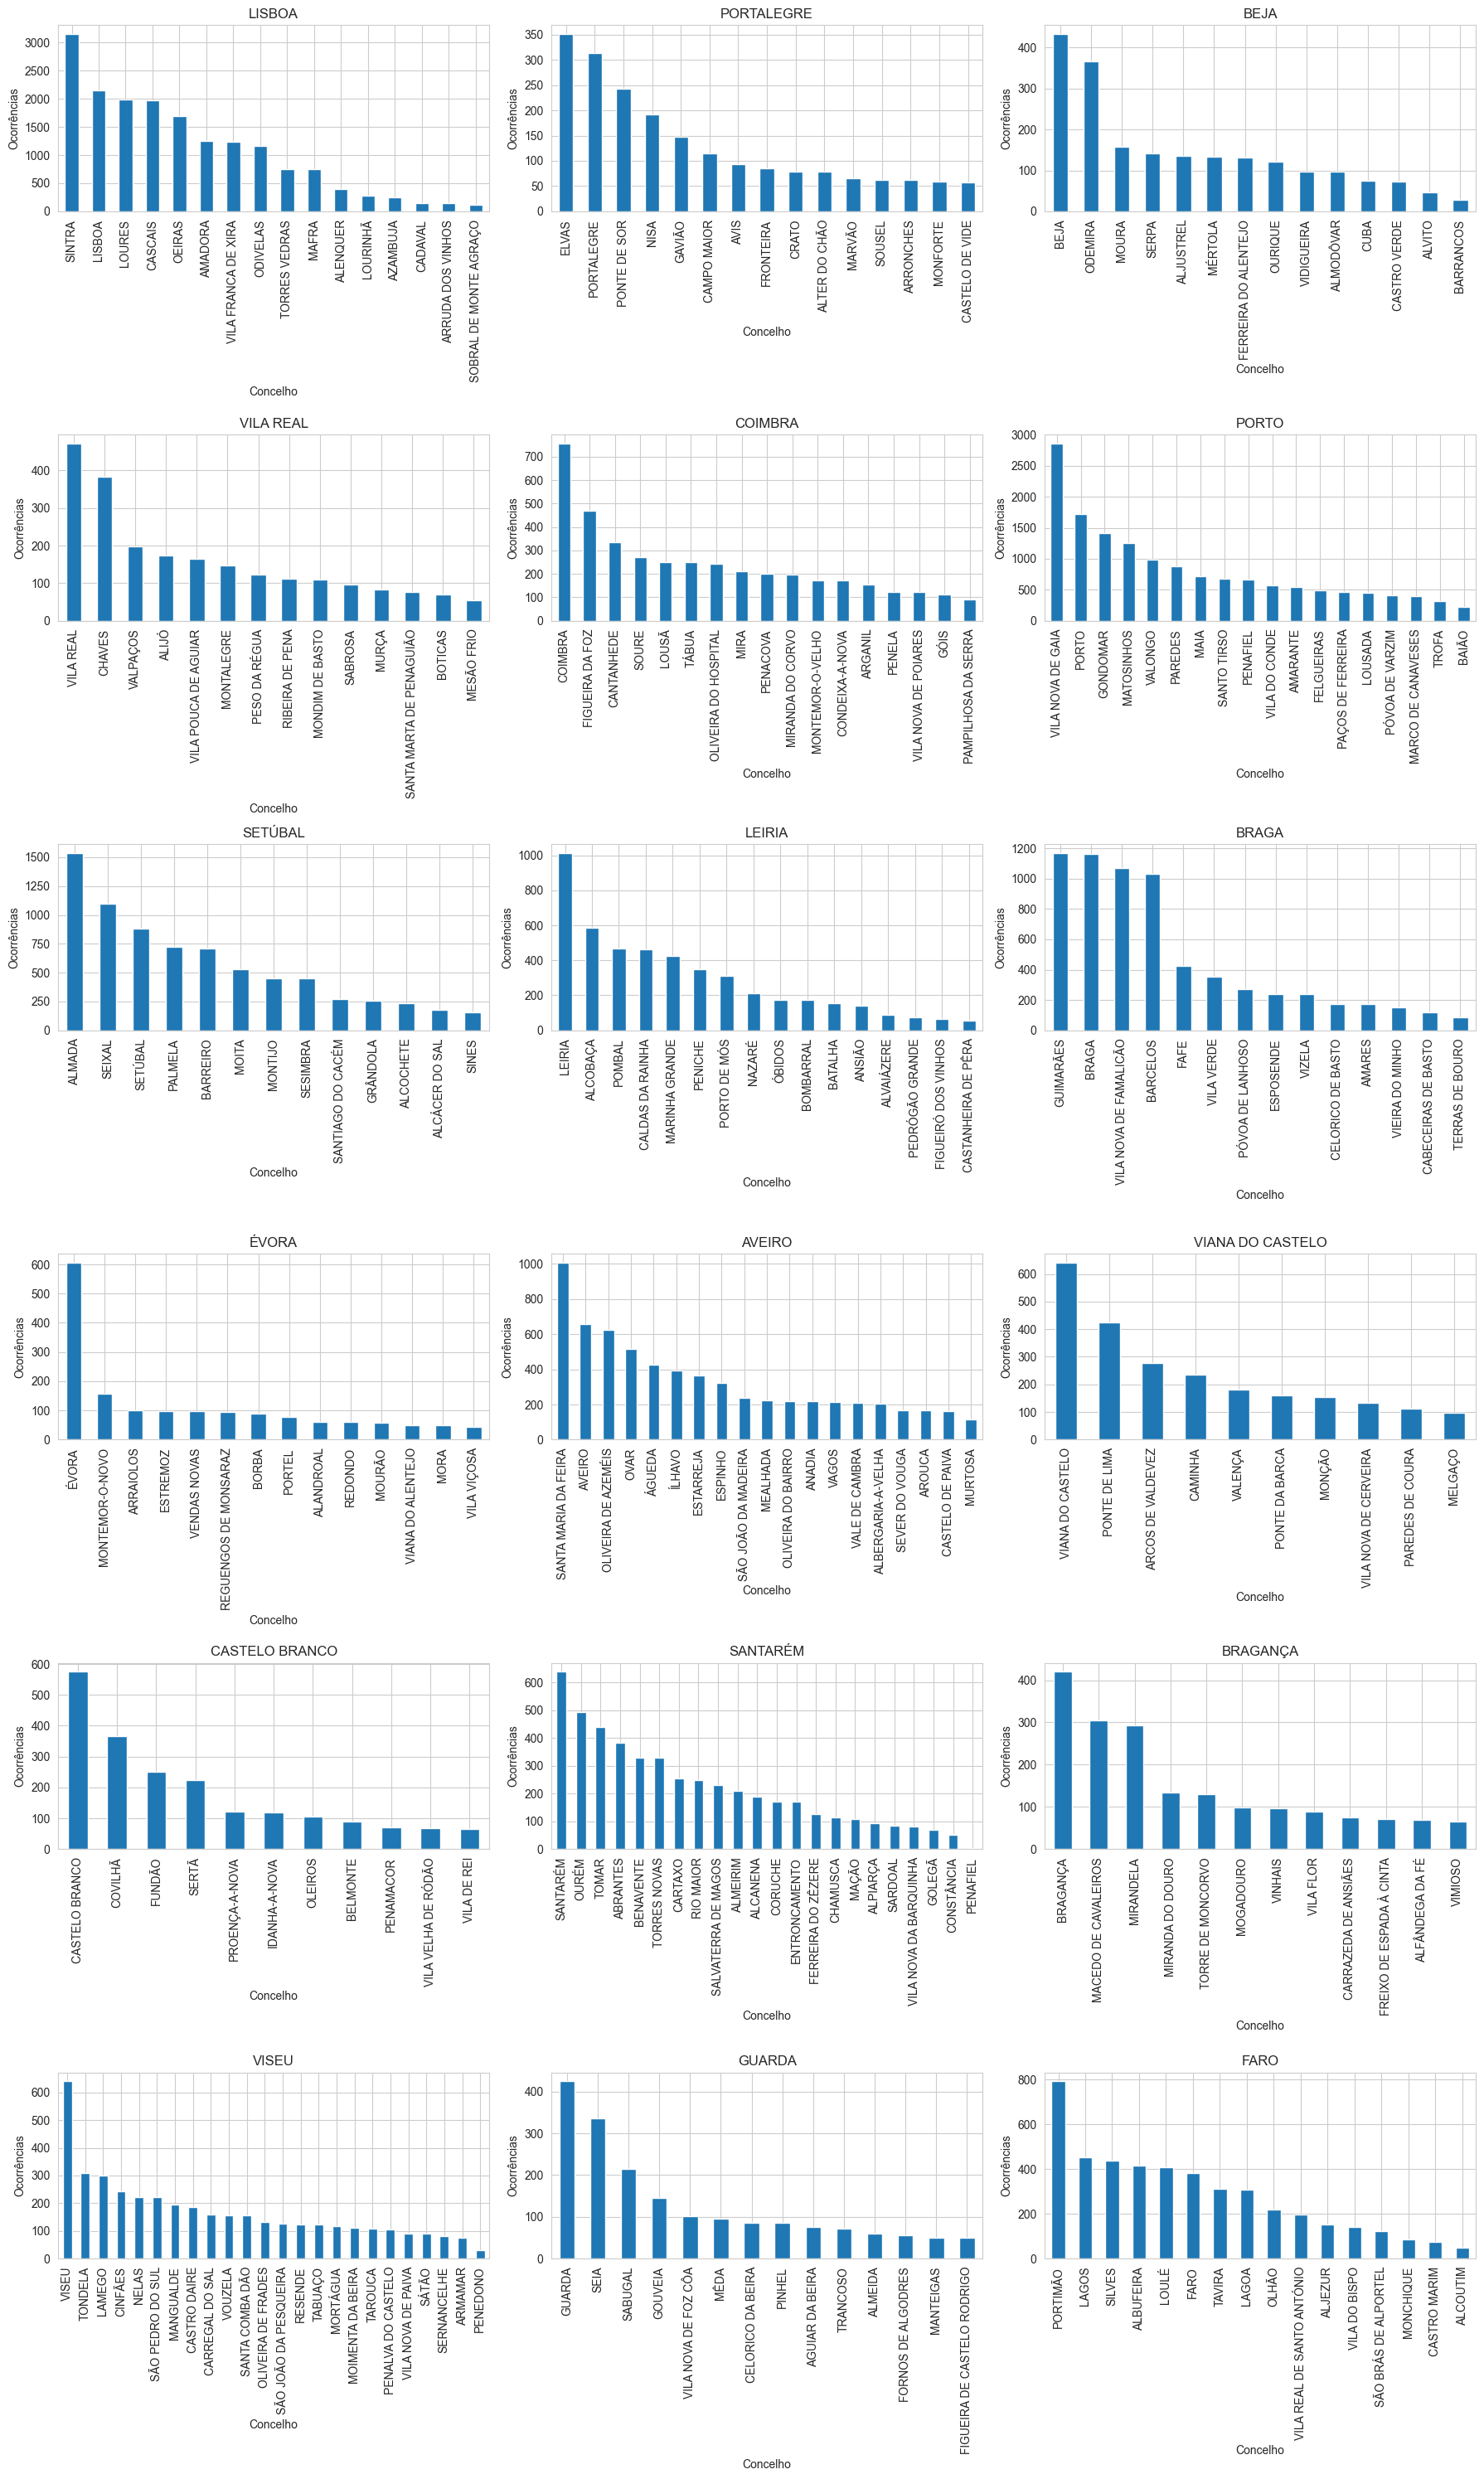

In [23]:
distritos = df['Distrito'].dropna().unique()
num_distritos = len(distritos)

# calcular quantidade de linhas e colunas
cols = 3
rows = math.ceil(num_distritos / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten()

for ax, dist in zip(axes, distritos):
    subset = df[df['Distrito'] == dist]
    counts_conc = subset['Concelho'].value_counts()

    counts_conc.plot(kind='bar', ax=ax)
    ax.set_title(f'{dist}')
    ax.set_xlabel('Concelho')
    ax.set_ylabel('Ocorrências')

# apagar subplots vazios
for i in range(len(distritos), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

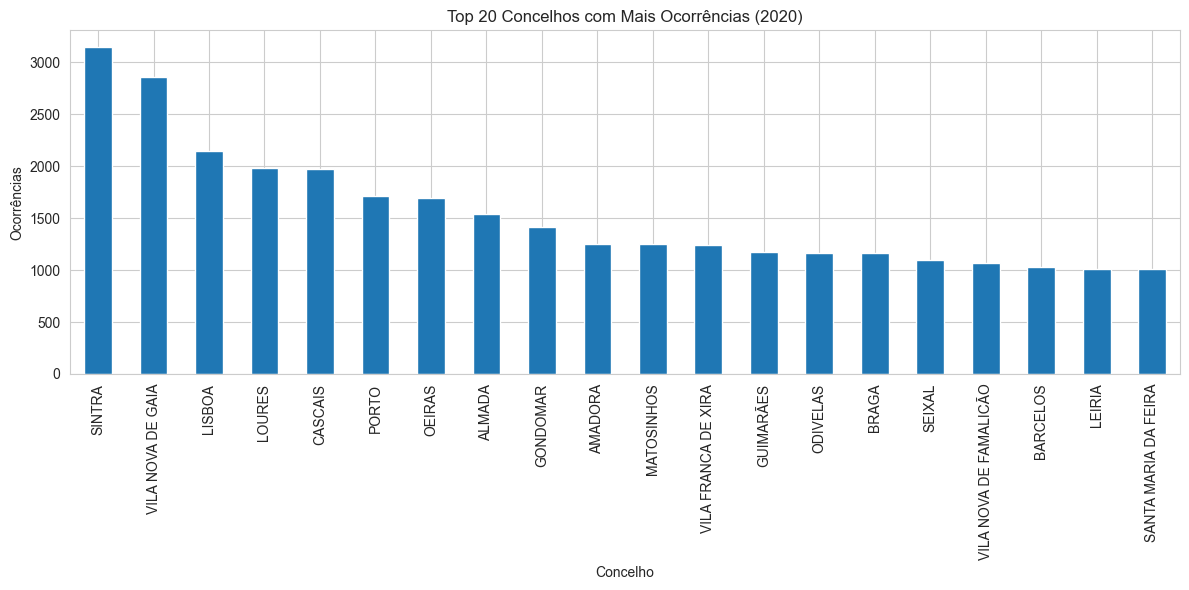

In [21]:
plt.figure(figsize=(12, 6))
df['Concelho'].value_counts().head(20).plot(kind='bar')

plt.title("Top 20 Concelhos com Mais Ocorrências (2020)")
plt.xlabel("Concelho")
plt.ylabel("Ocorrências")
plt.tight_layout()

plt.show()

In [33]:
counts_dist = df["Distrito"].value_counts().sort_values(ascending=False)
distritos = counts_dist.index.tolist()

def dashboard(distrito):
    # Criar figura a cada mudança -> garante atualização correta
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # --- Gráfico 1: Ocorrências por Distrito ---
    axes[0].bar(counts_dist.index, counts_dist.values)
    axes[0].set_title("Ocorrências por Distrito (2020)")
    axes[0].set_xlabel("Distrito")
    axes[0].set_ylabel("Ocorrências")
    axes[0].tick_params(axis='x', rotation=75)

    # --- Gráfico 2: Ocorrências por Concelho para o distrito escolhido ---
    conc_counts = (
        df[df["Distrito"] == distrito]["Concelho"]
        .value_counts()
        .sort_values(ascending=False)
    )

    axes[1].bar(conc_counts.index, conc_counts.values)
    axes[1].set_title(f"Ocorrências por Concelho — {distrito}")
    axes[1].set_xlabel("Concelho")
    axes[1].set_ylabel("Ocorrências")
    axes[1].tick_params(axis='x', rotation=75)

    plt.tight_layout()
    plt.show()


# Dropdown interativo
interact(
    dashboard,
    distrito=Dropdown(options=distritos, value=distritos[0], description='Distrito:')
)

interactive(children=(Dropdown(description='Distrito:', options=('LISBOA', 'PORTO', 'SETÚBAL', 'BRAGA', 'AVEIR…

<function __main__.dashboard(distrito)>

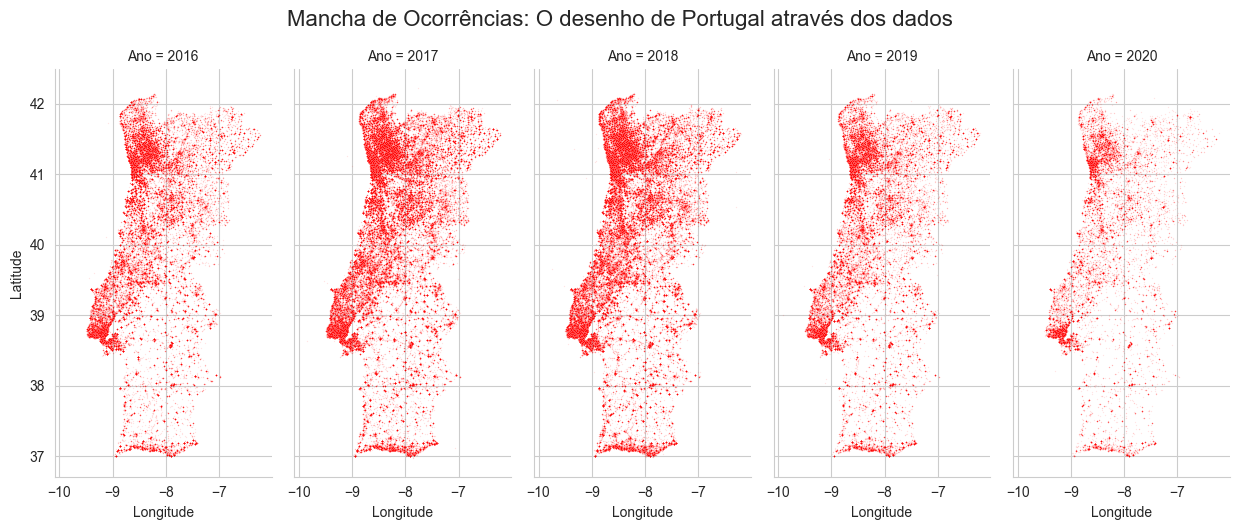

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filtrar para garantir que não temos coordenadas erradas (fora de Portugal continental aprox.)
# Latitude entre 36 e 42, Longitude entre -10 e -6
df_geo = df_total[
    (df_total['Latitude'] > 36) & (df_total['Latitude'] < 43) & 
    (df_total['Longitude'] > -10) & (df_total['Longitude'] < -6)
]

# Criar uma grelha de gráficos (1 linha, 5 colunas - uma para cada ano)
g = sns.FacetGrid(df_geo, col="Ano", height=5, aspect=0.5, col_wrap=5)

# Desenhar os pontos (Longitude no X, Latitude no Y)
# alpha=0.1 torna os pontos transparentes -> onde houver cor sólida, há MUITOS casos
g.map(sns.scatterplot, "Longitude", "Latitude", alpha=0.1, s=1, color='red')

g.fig.suptitle('Mancha de Ocorrências: O desenho de Portugal através dos dados', fontsize=16, y=1.05)
plt.show()


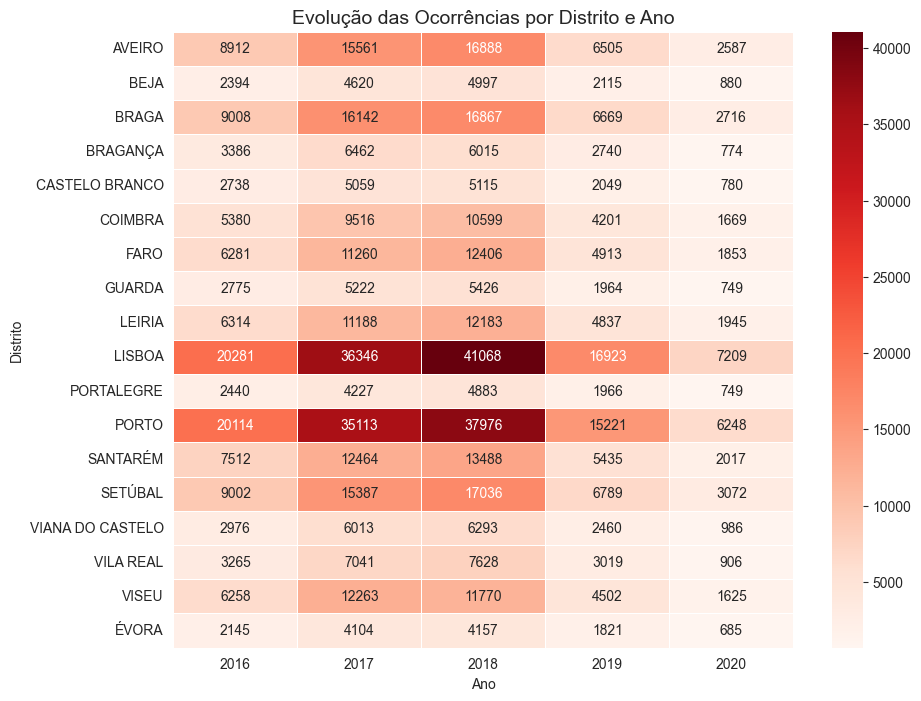

In [35]:
# 1. Preparar os dados: Tabela cruzada (Ano nas colunas, Distrito nas linhas)
tabela_calor = df_total.groupby(['Distrito', 'Ano']).size().unstack()

# 2. Desenhar o gráfico
plt.figure(figsize=(10, 8))
sns.heatmap(tabela_calor, 
            annot=True,     # Mostra os números dentro dos quadrados
            fmt='d',        # Formato numérico (inteiro)
            cmap='Reds',    # Escala de vermelhos
            linewidths=.5)  # Linhas brancas a separar

plt.title('Evolução das Ocorrências por Distrito e Ano', fontsize=14)
plt.show()

In [ ]:
Os distritos com maior número de ocorrências destacam-se claramente face aos restantes. 
Este resultado reforça a necessidade de uma abordagem diferenciada na gestão do risco, considerando as 
especificidades regionais e a intensidade da atividade registada em cada território.


## Conclusões

A análise exploratória dos dados permitiu identificar padrões relevantes na distribuição temporal, 
geográfica e tipológica das ocorrências registadas pela Proteção Civil. Verificou-se a existência de sazonalidade, 
bem como uma concentração significativa de ocorrências em determinados tipos e regiões. Apesar de algumas limitações 
relacionadas com a qualidade e completude dos dados, os resultados obtidos fornecem uma base sólida para o desenvolvimento 
de uma aplicação interativa em Streamlit, com potencial para apoiar a tomada de decisão e o planeamento operacional.

### Documentação do que aprendemos

In [ ]:
Resumo das Descobertas:
Natureza do Alvo: A variável NumeroOperacionaisTerrestresEnvolvidos é extremamente assimétrica (Skewed). A maioria dos eventos usa < 5 operacionais, mas existem eventos extremos (incêndios) com > 500.
Ação: É obrigatório usar uma transformação logarítmica (log1p) no alvo para treinar modelos de regressão linear ou redes neuronais.
Correlações:
Existe correlação óbvia com MeiosTerrestres (veículos).
A correlação direta linear com Hora ou Mes é baixa, o que indica que a relação é não-linear (ex: picos às 14h e descida às 04h não formam uma linha reta).
Baseline: O erro médio a bater é o calculado no passo 4. Se o nosso modelo futuro tiver um erro superior àquele valor, ele é pior que uma simples média.
Engenharia de Features:
O tempo deve ser tratado como cíclico (Seno/Cosseno).
A MacroCategoria é o preditor mais forte para a "Base" de operacionais.